In [1]:
!pip install torch tiktoken requests huggingface_hub matplotlib datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 15.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 49.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 74.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 13.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 71.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 135.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 114.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.2/801.2 kB 22.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30/30 [datasets]/30 [datasets]ce_hub]


In [2]:
CHECKPOINT_FILE = "/workspace/chkpt/tinygpt_pretrained_weights.pt"

In [3]:
import inspect
import torch
import torch.nn as nn
import torch.nn.functional as F
import os, requests
import shutil
import argparse
from dataclasses import dataclass
import tiktoken
from typing import Any
import matplotlib.pyplot as plt
import numpy as np

# Enable TF32 on matmuls (standard for Ampere+)
torch.set_float32_matmul_precision('high')

# --- Architecture ---
G_BLOCK_SIZE = 1024
G_N_EMBD    = 768
G_N_LAYERS  = 12
G_N_HEAD    = 12

# --- Hardware / Runtime ---
G_DROPOUT_PROB = 0.0   # mutated by callers (e.g. fine-tuning sets 0.1)
USE_BF16 = True
_HAS_MPS = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
G_DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if _HAS_MPS else "cpu")

# --- Infrastructure / Data ---
G_SEED = 1947
G_SPLIT_RATIO = 0.8
USE_SDP_ATTENTION = True
LOAD_CHECKPOINT = True
BINARY_DATASET_FILENAME = "dataset.bin"
#CHECKPOINT_FILE = "tinygpt_pretrained_weights.pt"
PLOT_TITLE = "Training vs Validation Loss — Pretraining"
PLOT_PATH  = "pretraining_loss_curve.png"


@dataclass
class Hyperparameters:
    lr:                   float = 6e-4
    weight_decay:         float = 0.1
    grad_clip:            float = 1.0
    warmup_iters:         int   = 1_800   # 6% of max_iters=30K
    max_iters:            int   = 30_000   # at eff_batch=512: ~15.7B tokens = 1.57 passes through FineWeb 10BT
    batch_size:           int   = 16
    effective_batch_size: int   = 512    # accumulation = effective_batch_size / batch_size
    eval_steps:           int   = 100    # evaluate every N training steps
    eval_iterations:      int   = 50     # batches averaged during validation
    patience:             int   = 6_000  # stop if no improvement for this many steps (~20% of max_iters)
    min_delta:            float = 0.01   # minimum improvement in val loss to reset patience

# Streaming dataset config (used when G_USE_STREAMING=True)
G_USE_STREAMING = True
STREAMING_HF_DATASET = "Skylion007/openwebtext"
STREAMING_HF_SUBSET = None # No subset, full dataset as its 9.4 GB only.
STREAMING_VAL_DOCS = 2000  # first 2000 documents reserved for validation
#Random seed for reproducibility
torch.manual_seed(G_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(G_SEED)

@dataclass
class State:
    tokenizer: Any
    train_data: Any  # np.ndarray when offline; None when streaming
    val_data: Any    # np.ndarray when offline; None when streaming
    vocab_size: int
    train_iter: Any = None  # infinite iterator over streaming train batches
    val_iter: Any = None    # infinite iterator over streaming val batches

def _infinite_iter(loader):
    """Wraps a DataLoader to yield batches forever, restarting when exhausted."""
    while True:
        for batch in loader:
            yield batch


class StreamingTokenDataset(torch.utils.data.IterableDataset):
    """Streams text from HuggingFace, tokenizes on-the-fly, and yields (x, y) pairs.

    The first STREAMING_VAL_DOCS documents are reserved for validation;
    all subsequent documents are used for training.
    """
    def __init__(self, split: str, block_size: int = G_BLOCK_SIZE):
        super().__init__()
        self.split = split
        self.block_size = block_size

    def __iter__(self):
        from datasets import load_dataset
        enc = tiktoken.get_encoding("gpt2")
        eot = enc.eot_token  # 50256 — appended between documents

        ds = load_dataset(
            STREAMING_HF_DATASET,
            STREAMING_HF_SUBSET,
            split="train",
            streaming=True,
        )

        if self.split == "val":
            ds = ds.take(STREAMING_VAL_DOCS)
        else:
            ds = ds.skip(STREAMING_VAL_DOCS)

        buffer = []
        for example in ds:
            tokens = enc.encode_ordinary(example["text"])
            tokens.append(eot)
            buffer.extend(tokens)
            while len(buffer) >= self.block_size + 1:
                chunk = buffer[: self.block_size + 1]
                yield (
                    torch.tensor(chunk[:-1], dtype=torch.long),
                    torch.tensor(chunk[1:], dtype=torch.long),
                )
                buffer = buffer[self.block_size + 1 :]


def build_state(split_ratio: float = G_SPLIT_RATIO, dataset_path: str | None = BINARY_DATASET_FILENAME, batch_size: int | None = None) -> State:
    if batch_size is None:
        batch_size = Hyperparameters().batch_size
    tokenizer = tiktoken.get_encoding("gpt2")
    vocab_size = tokenizer.n_vocab

    if G_USE_STREAMING:
        print(f"Streaming from {STREAMING_HF_DATASET} / {STREAMING_HF_SUBSET} ...")
        train_ds = StreamingTokenDataset(split="train", block_size=G_BLOCK_SIZE)
        val_ds   = StreamingTokenDataset(split="val",   block_size=G_BLOCK_SIZE)
        # num_workers=0 avoids multiprocessing issues with HuggingFace streaming on Windows
        train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, num_workers=0)
        val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=batch_size, num_workers=0)
        return State(
            tokenizer=tokenizer,
            train_data=None,
            val_data=None,
            vocab_size=vocab_size,
            train_iter=_infinite_iter(train_loader),
            val_iter=_infinite_iter(val_loader),
        )

    # Offline binary path (fallback)
    assert dataset_path is not None, "dataset_path required when G_USE_STREAMING=False"
    data = np.memmap(dataset_path, dtype=np.uint16, mode="r")
    data_len = len(data)
    split_idx = int(data_len * split_ratio)
    return State(tokenizer=tokenizer, train_data=data[:split_idx], val_data=data[split_idx:], vocab_size=vocab_size)

#Lets do some Self Attention
class SelfAttention(nn.Module):
    def __init__(self, n_embd):
        super().__init__()

        self.key = nn.Linear(G_N_EMBD, n_embd, bias=False)
        self.query = nn.Linear(G_N_EMBD, n_embd, bias=False)
        self.value = nn.Linear(G_N_EMBD, n_embd, bias=False)

        self.register_buffer(
            "mask", 
            torch.tril(torch.ones(G_BLOCK_SIZE, G_BLOCK_SIZE))
        )
        self.dropout = nn.Dropout(G_DROPOUT_PROB)

    def forward(self, x): # Attention = softmax(similarity(q, k)) @ v
        B, T, C = x.shape

        # Compute key, query, value projections for self-attention.
        q = self.query(x) # `q` (query): what each token is "asking for".
        k = self.key(x)  # `k` (key): content to be compared/matched against the query.
        
        weights1 = q @ k.transpose(-2, -1) / (C**0.5)
        weights1 = weights1.masked_fill(self.mask[:T, :T] == 0, float('-inf')) #Mask ensures auto regressive behavior
        weights1 = F.softmax(weights1, dim=-1)
        weights1 = self.dropout(weights1)

        v = self.value(x) # `v` (value): information returned.
        out = weights1 @ v

        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([SelfAttention(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(G_N_EMBD, G_N_EMBD, bias=False)
        self.dropout = nn.Dropout(G_DROPOUT_PROB)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.n_embd = n_embd
        assert n_embd % G_N_HEAD == 0
        # Key, Query, Value projections for all heads in one go
        self.c_attn = nn.Linear(n_embd, 3 * n_embd)
        # Output projection
        self.c_proj = nn.Linear(n_embd, n_embd)
        self.c_proj.TINYGPT_SCALE_INIT = True # Indicate to scale weight initialization by sqrt(2*n_layer) for better convergence
        # Regularization
        self.attn_dropout = nn.Dropout(G_DROPOUT_PROB)
        self.resid_dropout = nn.Dropout(G_DROPOUT_PROB)
        
        self.register_buffer("mask", torch.tril(torch.ones(G_BLOCK_SIZE, G_BLOCK_SIZE))
                                        .view(1, 1, G_BLOCK_SIZE, G_BLOCK_SIZE))

    def forward(self, x):
        B, T, C = x.size()
        # Calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, G_N_HEAD, C // G_N_HEAD).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, G_N_HEAD, C // G_N_HEAD).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, G_N_HEAD, C // G_N_HEAD).transpose(1, 2) # (B, nh, T, hs)

        # Causal self-attention
        if USE_SDP_ATTENTION and hasattr(F, "scaled_dot_product_attention"):
            y = F.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=G_DROPOUT_PROB if self.training else 0.0,
                is_causal=True,
            )
        else:
            # Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
            att = (q @ k.transpose(-2, -1)) * (1.0 / (k.size(-1)**0.5))
            att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # Re-assemble all head outputs side by side

        # Output projection
        y = self.resid_dropout(self.c_proj(y))
        return y
    
# Transformer block: self-attention plus feed-forward network
class Block(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
 
        # Each head gets an equal portion of the embedding dimension
        self.ln1 = nn.LayerNorm(n_embd)
        #self.attention = MultiHeadAttention(G_N_HEAD, n_embd // G_N_HEAD)
        self.attention = CausalSelfAttention(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

        ff3 = nn.Linear(4*n_embd, n_embd, bias=False)
        ff3.TINYGPT_SCALE_INIT = True # Indicate to scale weight initialization by sqrt(2*n_layer) for better convergence
        self.feed_forward = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd, bias=False),
            nn.GELU(),
            ff3,
            nn.Dropout(G_DROPOUT_PROB),
        )

    def forward(self, x):
        x = x + self.attention(self.ln1(x))
        x = x + self.feed_forward(self.ln2(x))

        return x

def configure_optimizers(model: nn.Module, weight_decay: float, learning_rate: float, device_type: str):
    param_dict = {pn: p for pn, p in model.named_parameters() if p.requires_grad}
    decay_params   = [p for _, p in param_dict.items() if p.dim() >= 2]
    nodecay_params = [p for _, p in param_dict.items() if p.dim() < 2]
    optim_groups = [
        {'params': decay_params,   'weight_decay': weight_decay},
        {'params': nodecay_params, 'weight_decay': 0.0},
    ]
    num_decay_params   = sum(p.numel() for p in decay_params)
    num_nodecay_params = sum(p.numel() for p in nodecay_params)
    print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
    print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
    fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
    use_fused = fused_available and device_type == "cuda"
    print(f"using fused AdamW: {use_fused}")
    optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
    return optimizer

def build_optimizer_scheduler(model: nn.Module, weight_decay: float, learning_rate: float,
                              device_type: str, warmup_iters: int, max_iters: int):
    optimizer = configure_optimizers(
        model=model,
        weight_decay=weight_decay,
        learning_rate=learning_rate,
        device_type=device_type)

    scheduler_warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0,
        total_iters=warmup_iters)

    scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=(max_iters - warmup_iters),
        eta_min=0.1 * learning_rate)

    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[scheduler_warmup, scheduler_cosine],
        milestones=[warmup_iters],
    )
    return optimizer, scheduler

def compute_loss(
    model: nn.Module,
    x: torch.Tensor,
    y: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    """Forward pass + cross-entropy loss.

    mask=None → plain mean cross-entropy (pretraining).
    mask provided → masked mean, averaging only over real (non-padding) tokens (fine-tuning).
    """
    logits = model(x)
    B, T, C = logits.shape
    if mask is None:
        return F.cross_entropy(logits.view(B * T, C), y.view(B * T))
    loss = F.cross_entropy(logits.view(B * T, C), y.view(B * T), reduction="none")
    loss = loss * mask.view(B * T)
    return loss.sum() / mask.sum()


@torch.no_grad()
def evaluate_loss(
    model: nn.Module,
    get_batch_fn,
    eval_iters: int,
    device: str,
    use_bf16: bool,
) -> torch.Tensor:
    """Average loss over eval_iters batches for a stable validation metric.

    get_batch_fn must return (x, y, mask) where mask may be None (pretraining).
    """
    was_training = model.training
    model.eval()
    losses = torch.zeros(eval_iters, device=device)
    for k in range(eval_iters):
        x, y, mask = get_batch_fn()
        if device == "cuda" and use_bf16:
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                losses[k] = compute_loss(model, x, y, mask)
        else:
            losses[k] = compute_loss(model, x, y, mask)
    if was_training:
        model.train()
    return losses.mean()


#Lets Create the GPT model
class TinyGPT(nn.Module):
    def __init__(self, state: State, hparams: Hyperparameters | None = None):
        super().__init__()

        self.state = state
        self.hparams = hparams or Hyperparameters()
        self.token_embedding_table = nn.Embedding(state.vocab_size, G_N_EMBD)
        self.position_embedding_table = nn.Embedding(G_BLOCK_SIZE, G_N_EMBD)

        self.blocks = nn.Sequential(*[Block(G_N_EMBD) for _ in range(G_N_LAYERS)]) #Stacking multiple blocks for deeper architecture

        self.ln_f = nn.LayerNorm(G_N_EMBD)
        self.head = nn.Linear(G_N_EMBD, state.vocab_size, bias=False)

        self.apply(self._init_weights)
        # Weight tying: lm_head and token embedding share the same matrix.
        # Saves 38.6M params (768×50257); standard in GPT-2 / nanoGPT.
        self.head.weight = self.token_embedding_table.weight

    def forward(self, idx):
        B, T = idx.shape

        tok = self.token_embedding_table(idx)
        pos = self.position_embedding_table(torch.arange(T, device=G_DEVICE))

        x = tok + pos
        x = self.blocks(x)
        x = self.ln_f(x) #normalizes the hidden states
        logits = self.head(x) #final projection to logits for each token in the vocabulary
        return logits

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'TINYGPT_SCALE_INIT'):
                std *= (2 * G_N_LAYERS) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    #Load the batch from the dataset
    def _get_batch(self, split: str = "train"):
        if G_USE_STREAMING:
            iterator = self.state.train_iter if split == "train" else self.state.val_iter
            x, y = next(iterator)
            return x.to(G_DEVICE), y.to(G_DEVICE)

        data = self.state.train_data if split == "train" else self.state.val_data
        ix = torch.randint(len(data) - G_BLOCK_SIZE - 1, (self.hparams.batch_size,))

        # Convert the full batch slice in one go, then reshape to reduce overhead.
        ix_np = ix.cpu().numpy()
        offsets = np.arange(G_BLOCK_SIZE + 1)
        # Index memmap directly to avoid materializing the full dataset in RAM.
        batch = data[ix_np[:, None] + offsets]
        x = torch.from_numpy(batch[:, :-1]).long()
        y = torch.from_numpy(batch[:, 1:]).long()
        return x.to(G_DEVICE), y.to(G_DEVICE)

    def train_loop(self, get_batch_fn=None) -> None:
        hp = self.hparams
        optimizer, scheduler = build_optimizer_scheduler(
            self, hp.weight_decay, hp.lr, G_DEVICE, hp.warmup_iters, hp.max_iters)

        assert hp.effective_batch_size % hp.batch_size == 0, \
            "effective_batch_size must be divisible by batch_size"
        accumulation_steps = hp.effective_batch_size // hp.batch_size

        print(f"Total parameters: {sum(p.numel() for p in self.parameters())/1e6:.2f}M")
        print(f"Effective batch size: {hp.effective_batch_size} (via {accumulation_steps} accumulation steps)")

        start_step, best_val_loss = maybe_load_checkpoint(
            self, optimizer, scheduler,
            resume_path=CHECKPOINT_FILE if LOAD_CHECKPOINT else None)

        # Resolve batch functions once — both return (x, y, mask)
        if get_batch_fn is not None:
            train_fn = lambda: get_batch_fn("train")
            val_fn   = lambda: get_batch_fn("val")
        else:
            train_fn = lambda: (*self._get_batch("train"), None)
            val_fn   = lambda: (*self._get_batch("val"), None)

        steps = []
        train_losses = []
        val_losses = []
        steps_since_best = 0
        for step in range(start_step, hp.max_iters):
            # 1. Accumulate gradients over multiple micro-batches
            optimizer.zero_grad(set_to_none=True)
            micro_step_loss = 0.0

            for _ in range(accumulation_steps):
                x, y, mask = train_fn()
                if G_DEVICE == "cuda" and USE_BF16:
                    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                        loss = compute_loss(self, x, y, mask)
                else:
                    loss = compute_loss(self, x, y, mask)
                # Scale loss by accumulation steps so gradients are averaged correctly
                scaled_loss = loss / accumulation_steps
                scaled_loss.backward()
                micro_step_loss += loss.item()

            avg_train_loss = micro_step_loss / accumulation_steps

            # 2. Clip and update weights
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=hp.grad_clip)
            optimizer.step()
            scheduler.step()

            # 3. Logging and Checkpointing
            if (step + 1) % hp.eval_steps == 0 or step == start_step:
                val_loss = evaluate_loss(
                    self, val_fn, hp.eval_iterations, G_DEVICE, USE_BF16,
                )
                steps.append(step + 1)
                train_losses.append(avg_train_loss)
                val_losses.append(val_loss.item())
                marker = " *** best ***" if val_loss.item() < best_val_loss else ""
                print(f"step {step+1}: train {avg_train_loss:.4f} | val {val_loss.item():.4f}{marker}")

                prev_best = best_val_loss
                best_val_loss = maybe_save_checkpoint(
                    model=self, optimizer=optimizer, scheduler=scheduler,
                    vocab_size=self.state.vocab_size, step=step,
                    save_path=CHECKPOINT_FILE, val_loss=val_loss.item(),
                    best_val_loss=best_val_loss,
                )

                if prev_best - val_loss.item() >= hp.min_delta:
                    steps_since_best = 0
                else:
                    steps_since_best += hp.eval_steps
                    if steps_since_best >= hp.patience:
                        print(f"Early stopping at step {step+1}: no improvement > {hp.min_delta} for {hp.patience} steps.")
                        break

        plot_losses(steps, train_losses, val_losses, title=PLOT_TITLE, output_path=PLOT_PATH)

    # Text Generation Function
    def generate_text(self, start_text, max_tokens=50, temperature=0.7, top_k=None):
        self.eval()

        tokens = self.state.tokenizer.encode(start_text)
        idx = torch.tensor(tokens).unsqueeze(0).to(G_DEVICE)

        for _ in range(max_tokens):
            idx_cond = idx[:, -G_BLOCK_SIZE:]
            logits = self(idx_cond)
            logits = logits[:, -1, :]
            logits = logits / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)
            if idx_next.item() == self.state.tokenizer.eot_token:
                break
            idx = torch.cat((idx, idx_next), dim=1)

        text = self.state.tokenizer.decode(idx[0].tolist())
        return text

def maybe_load_checkpoint(
    model: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
    scheduler: Any = None,
    resume_path: str | None = CHECKPOINT_FILE,
    device: str = G_DEVICE,
) -> tuple[int, float]:
    if not resume_path:
        return 0, float("inf")

    if not os.path.exists(resume_path):
        print(f"Checkpoint not found at {resume_path}. Starting fresh.")
        return 0, float("inf")

    ckpt = torch.load(resume_path, map_location=device, weights_only=False)
    # Support both full training checkpoints (dict with "model_state" key)
    # and bare state dicts saved for inference-only use.
    if isinstance(ckpt, dict) and "model_state" in ckpt:
        state_dict = ckpt["model_state"]
        if optimizer is not None:
            optimizer.load_state_dict(ckpt["optimizer_state"])
        if scheduler is not None and ckpt.get("scheduler_state") is not None:
            scheduler.load_state_dict(ckpt["scheduler_state"])
        start_step = int(ckpt.get("step", 0)) + 1
        best_val_loss = float(ckpt.get("val_loss", float("inf")))
        print(f"Resumed from {resume_path} at step {start_step}")
    else:
        state_dict = ckpt
        start_step = 0
        best_val_loss = float("inf")
        print(f"Loaded weights from {resume_path}")
    # Checkpoints saved from torch.compile'd models have an "_orig_mod." prefix on all keys.
    # Strip it so weights load into either compiled or non-compiled models without error.
    if any(k.startswith("_orig_mod.") for k in state_dict):
        state_dict = {k.removeprefix("_orig_mod."): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict)
    return start_step, best_val_loss

def maybe_save_checkpoint(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: Any = None,
    step: int = 0,
    vocab_size: int = 0,
    save_path: str | None = CHECKPOINT_FILE,
    val_loss: float | None = None,
    best_val_loss: float = float("inf"),
) -> float:
    if save_path is None or val_loss is None or val_loss >= best_val_loss:
        return best_val_loss

    payload = {
        "step": step,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "vocab_size": vocab_size,
        "val_loss": val_loss,
    }
    if scheduler is not None:
        try:
            payload["scheduler_state"] = scheduler.state_dict()
        except Exception:
            payload["scheduler_state"] = None
    torch.save(payload, save_path)
    print(f"Saved checkpoint: {save_path} (val {val_loss:.4f})")
    return val_loss

def plot_losses(steps, train_losses, val_losses,
                 title: str = "Training vs Validation Loss — Pretraining",
                 output_path: str = "pretraining_loss_curve.png",
                 dpi: int = 100):
    if not steps:
        return
    plt.figure(figsize=(10, 6))
    plt.plot(steps, train_losses, label="train")
    plt.plot(steps, val_losses, label="val")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=dpi)
    plt.show()
    plt.close()
    print(f"Loss curve saved to {output_path}")

# Code for runing inference
def _ensure_dataset():
    # if dataset.bin does not exist, download it.
    if not os.path.exists(BINARY_DATASET_FILENAME):
        from huggingface_hub import hf_hub_download
        # Download the specific .bin file from your repository
        repo_id = "hemantvirmani/gpt-training-dataset"
        filename = "dataset.bin"

        print(f"Downloading {filename} from Hugging Face...")
        file_path = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset")
        shutil.copyfile(file_path, BINARY_DATASET_FILENAME)
    return BINARY_DATASET_FILENAME

def save_weights(output_path: str, checkpoint_path: str | None = CHECKPOINT_FILE) -> None:
    """Extract and save only model weights from a training checkpoint.

    Strips optimizer/scheduler state and any torch.compile key prefixes.
    The resulting file is ~3x smaller and loads instantly for inference.
    Runs fine on CPU — no GPU needed.
    """
    src = checkpoint_path or CHECKPOINT_FILE
    ckpt = torch.load(src, map_location="cpu", weights_only=False)
    state_dict = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
    if any(k.startswith("_orig_mod.") for k in state_dict):
        state_dict = {k.removeprefix("_orig_mod."): v for k, v in state_dict.items()}
    torch.save(state_dict, output_path)
    size_mb = os.path.getsize(output_path) / 1024 / 1024
    print(f"Saved weights to {output_path} ({size_mb:.0f} MB)")

def load_model_for_inference() -> TinyGPT:
    """Load model weights from checkpoint and return an eval-ready model."""
    tokenizer = tiktoken.get_encoding("gpt2")
    state = State(tokenizer=tokenizer, train_data=None, val_data=None, vocab_size=tokenizer.n_vocab)
    model = TinyGPT(state).to(G_DEVICE)
    maybe_load_checkpoint(model)  # return values not needed for inference
    model.eval()
    return model


Streaming from Skylion007/openwebtext / None ...
num decayed parameter tensors: 50, with 124,318,464 parameters
num non-decayed parameter tensors: 74, with 75,264 parameters
using fused AdamW: True
Total parameters: 124.39M
Effective batch size: 512 (via 32 accumulation steps)
Checkpoint not found at /workspace/chkpt/tinygpt_pretrained_weights.pt. Starting fresh.


README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

step 23200: train 3.0693 | val 3.0382
step 23300: train 3.0513 | val 3.0272
step 23400: train 3.0350 | val 3.0157


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

step 23500: train 3.0745 | val 3.0222
Early stopping at step 23500: no improvement > 0.01 for 6000 steps.


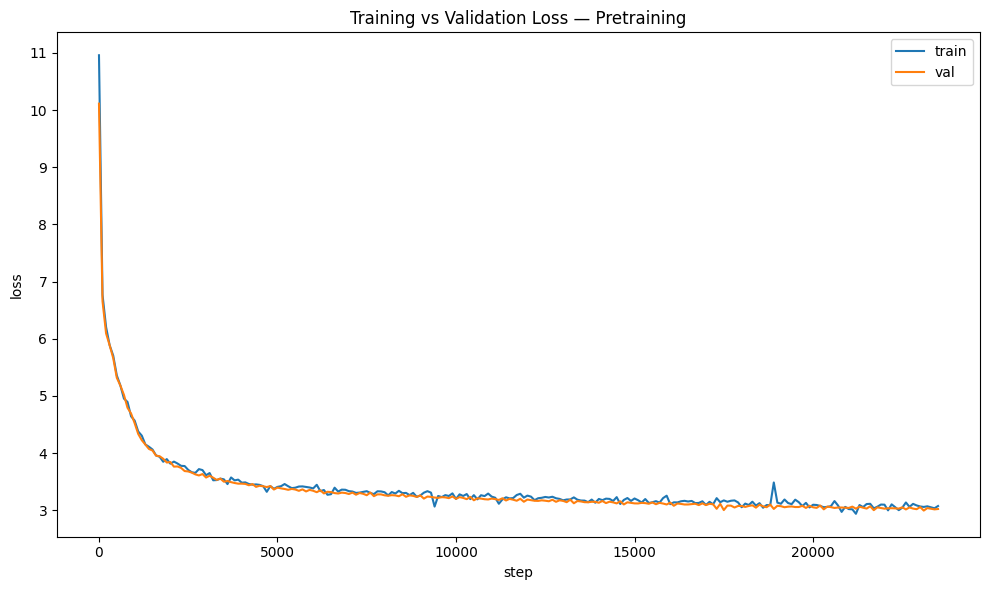

Loss curve saved to pretraining_loss_curve.png
USA is a country of _________. My thoughts on this matter are not on the legalities of the case. The reason the matter is so important is to protect the country from any possible future threat.

By declaring the case in a worldwide jurisdiction, the US government has assured that it will not challenge any travel ban, and will use the court’s ruling to establish that travel bans may not be imposed at the same time.

The case is valid in the United States, and is a legal basis for the case.

The most important thing is that this case is meant to go forward, and should be decided in the relevant court.

The US government is clearly struggling to argue that the case is valid, and that this case is a victory for the free-market.

On July 1, 2013, the US House of Representatives passed a resolution condemning the “unlawful assembly and unlawful assembly” in Iran’s streets.

The resolution calls on the “executive leaders of the world’s major oil 

In [4]:
def main():
    parser = argparse.ArgumentParser(description="Train TinyGPT or run inference.")
    parser.add_argument("--infer", type=str, help="Run inference with the given prompt.")
    args, _ = parser.parse_known_args()

    if args.infer:
        model = load_model_for_inference()
        print(model.generate_text(start_text=args.infer, max_tokens=1000))
        return

    file_path = _ensure_dataset() if not G_USE_STREAMING else None
    # build the state and train the model
    hparams = Hyperparameters()
    state = build_state(dataset_path=file_path, batch_size=hparams.batch_size)
    model = TinyGPT(state, hparams=hparams).to(G_DEVICE)
    if G_DEVICE == "cuda": model = torch.compile(model)
    model.train_loop()

    # Lets generate some text from the trained model
    print(model.generate_text(start_text="USA is a country of ", max_tokens=1000))

if __name__ == "__main__":
    main()